# GAN Monet Painting Dataset


## Problem Statement

The main goal of this project is to design, train, and evaluate a GAN model that can generate Monet-style paintings from input photographs.


# Exploratory Data Analysis (EDA) 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import os
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import sklearn
from tqdm import tqdm
import IPython

Total number of Monet images: 300


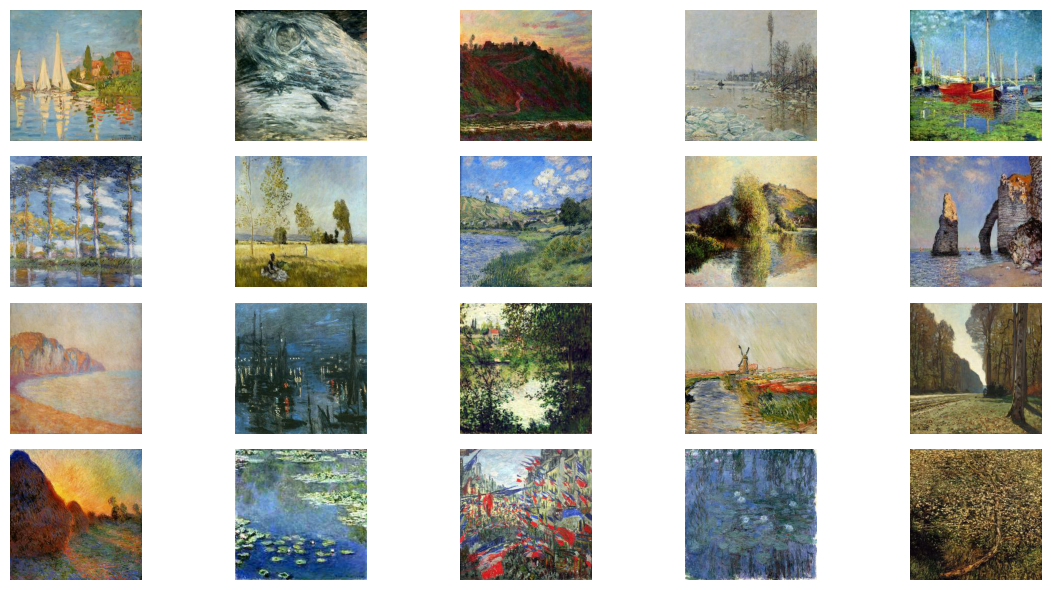

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import glob

monet_paths = glob.glob("gan-getting-started/monet_jpg/*.jpg")

print(f'Total number of Monet images: {len(monet_paths)}')

fig, axes = plt.subplots(4, 5, figsize=(12, 6))

for ax, img_path in zip(axes.flatten(), monet_paths[:20]):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [3]:
from PIL import Image
import pandas as pd

image_sizes = []

for img_path in monet_paths:
    img = Image.open(img_path)
    image_sizes.append(img.size)

df_sizes = pd.DataFrame(image_sizes, columns=['Width', 'Height'])

print(df_sizes.head())

df_sizes.describe()


   Width  Height
0    256     256
1    256     256
2    256     256
3    256     256
4    256     256


,Width,Height
count,300.0,300.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


### **Examining Color Distribution**


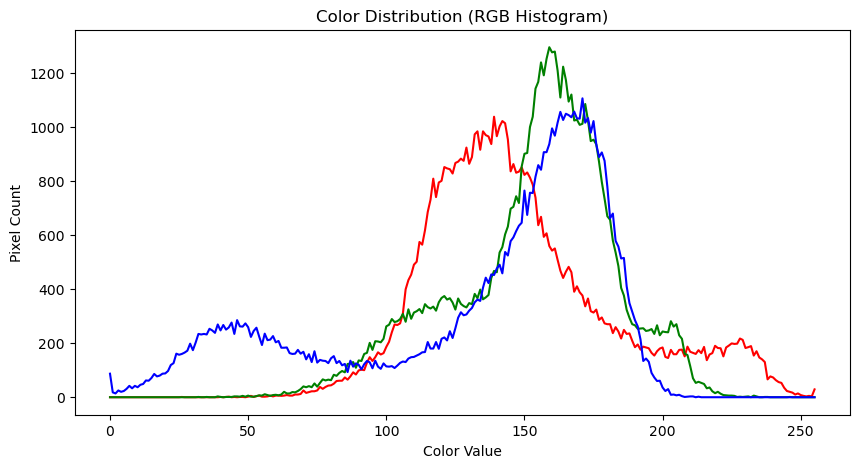

In [4]:
import cv2
import numpy as np

img = cv2.imread(monet_paths[0])  
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
color = ('r', 'g', 'b')
for i, col in enumerate(color):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)

plt.title("Color Distribution (RGB Histogram)")
plt.xlabel("Color Value")
plt.ylabel("Pixel Count")
plt.show()


### **Understanding the Edges and Structure of Images**

Purpose: To analyze the edge structure and level of detail of Monet's paintings.

In [5]:
import cv2
import numpy as np

def image_difference(img1_path, img2_path):
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
    img1 = cv2.resize(img1, (256, 256))
    img2 = cv2.resize(img2, (256, 256))
    return np.mean(np.abs(img1 - img2))

for i in range(5):
    for j in range(i+1, 5):
        diff = image_difference(monet_paths[i], monet_paths[j])
        print(f"Difference between image {i} and {j}: {diff}")


Difference between image 0 and 1: 119.88584899902344
Difference between image 0 and 2: 128.29019165039062
Difference between image 0 and 3: 145.81924438476562
Difference between image 0 and 4: 109.09211730957031
Difference between image 1 and 2: 116.45121765136719
Difference between image 1 and 3: 129.5623016357422
Difference between image 1 and 4: 125.66720581054688
Difference between image 2 and 3: 138.591552734375
Difference between image 2 and 4: 132.8683319091797
Difference between image 3 and 4: 99.60490417480469


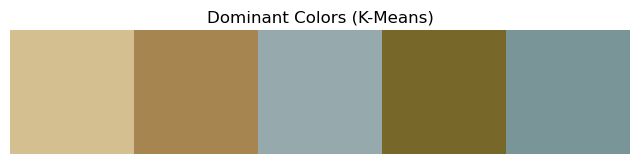

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

img = cv2.imread(monet_paths[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.reshape((-1, 3))

kmeans = KMeans(n_clusters=5)
kmeans.fit(img)
colors = kmeans.cluster_centers_

plt.figure(figsize=(8, 2))
plt.imshow([colors.astype(int)])
plt.axis("off")
plt.title("Dominant Colors (K-Means)")
plt.show()


In [7]:
# 1. Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os

# 2. Generator Model 

In [8]:
class MyGenNet(nn.Module):
    def __init__(self):
        super(MyGenNet, self).__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x

In [9]:
class MyDiscNet(nn.Module):
    def __init__(self):
        super(MyDiscNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 1, 4, 1, 1)
        )
    def forward(self, x):
        return self.net(x)

# Data Preparation

In [10]:
data_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class ImageFolderFlat(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

photo_dir = 'gan-getting-started/photo_jpg'
monet_dir = 'gan-getting-started/monet_jpg'

photo_imgs = [os.path.join(photo_dir, fname) for fname in os.listdir(photo_dir)]
monet_imgs = [os.path.join(monet_dir, fname) for fname in os.listdir(monet_dir)]

photo_data = ImageFolderFlat(photo_imgs, data_transform)
monet_data = ImageFolderFlat(monet_imgs, data_transform)

photo_loader = DataLoader(photo_data, batch_size=16, shuffle=True)
monet_loader = DataLoader(monet_data, batch_size=16, shuffle=True)

# Setup Model and Training Components

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen = MyGenNet().to(device)
disc = MyDiscNet().to(device)

adv_loss_fn = nn.MSELoss()
cycle_loss_fn = nn.L1Loss()
id_loss_fn = nn.L1Loss()
g_opt = optim.Adam(gen.parameters(), lr=1e-4, betas=(0.5, 0.999))
d_opt = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.999))

# Training Loop

In [12]:

num_epochs = 10
for epoch in range(num_epochs):
    for (photos, monets) in zip(photo_loader, monet_loader):
        photos, monets = photos.to(device), monets.to(device)

        # --- Generator step ---
        g_opt.zero_grad()
        fake_monets = gen(photos)
        validity = disc(fake_monets)
        g_loss = adv_loss_fn(validity, torch.ones_like(validity))
        g_loss = g_loss + cycle_loss_fn(gen(fake_monets), photos)
        g_loss = g_loss + id_loss_fn(gen(photos), photos)
        g_loss.backward()
        g_opt.step()

        # --- Discriminator step ---
        d_opt.zero_grad()
        real_valid = disc(monets)
        fake_valid = disc(fake_monets.detach())
        d_loss = (adv_loss_fn(real_valid, torch.ones_like(real_valid)) +
                  adv_loss_fn(fake_valid, torch.zeros_like(fake_valid))) / 2
        d_loss.backward()
        d_opt.step()

    print(f"Epoch {epoch+1}/{num_epochs} | G Loss: {g_loss.item():.4f} | D Loss: {d_loss.item():.4f}")




Epoch 1/10 | G Loss: 1.0135 | D Loss: 0.2759
Epoch 2/10 | G Loss: 0.8852 | D Loss: 0.2383
Epoch 3/10 | G Loss: 0.8414 | D Loss: 0.2564
Epoch 4/10 | G Loss: 0.7485 | D Loss: 0.2595
Epoch 5/10 | G Loss: 0.7483 | D Loss: 0.2172
Epoch 6/10 | G Loss: 0.6460 | D Loss: 0.2903
Epoch 7/10 | G Loss: 0.7156 | D Loss: 0.2509
Epoch 8/10 | G Loss: 0.6499 | D Loss: 0.2256
Epoch 9/10 | G Loss: 0.7630 | D Loss: 0.2587
Epoch 10/10 | G Loss: 0.6695 | D Loss: 0.2934


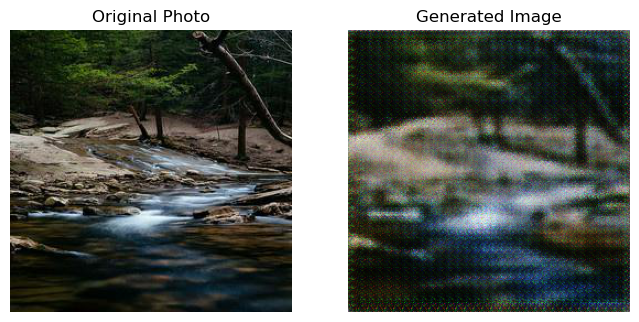

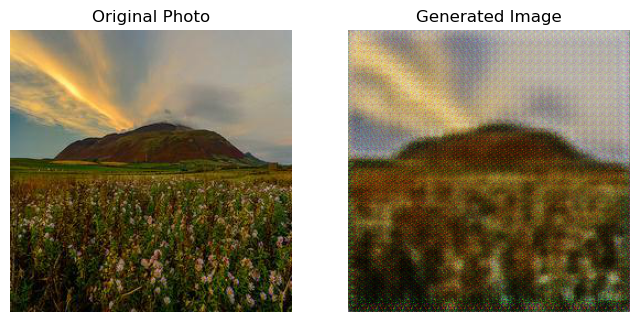

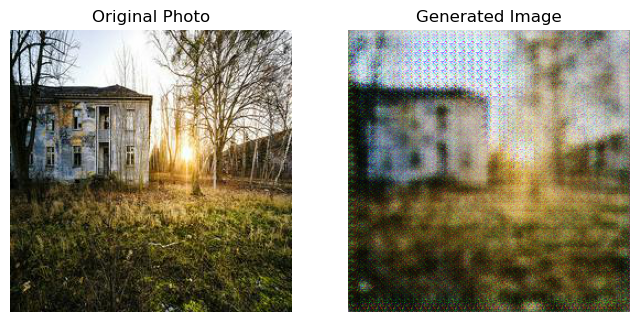

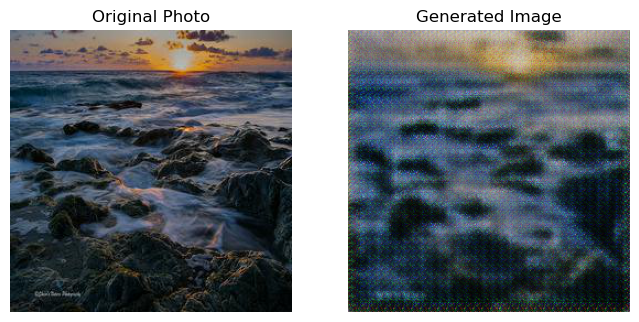

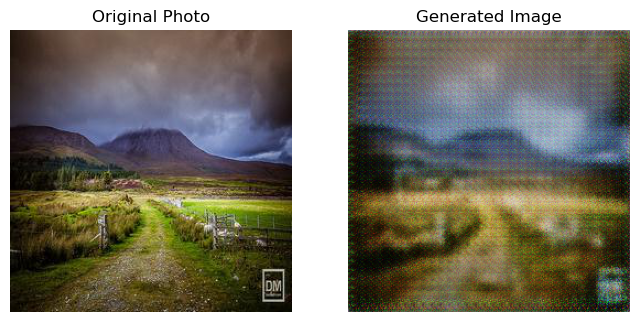

In [13]:
import matplotlib.pyplot as plt
import torch

def show_real_vs_generated(photo_loader, generator, device, num_samples=5):
    """
    Visualizes real input images vs generated output images from your generator.
    """
    generator.eval()
    cnt = 0

    with torch.no_grad():
        for photos in photo_loader:
            photos = photos.to(device)
            generated = generator(photos)
            # Denormalize for display
            generated = (generated * 0.5) + 0.5
            photos = (photos * 0.5) + 0.5

            for i in range(min(num_samples, photos.size(0))):
                plt.figure(figsize=(8, 4))

                # Show real photo
                plt.subplot(1, 2, 1)
                plt.imshow(photos[i].cpu().permute(1, 2, 0).clamp(0, 1))
                plt.title("Original Photo")
                plt.axis("off")

                # Show generated image
                plt.subplot(1, 2, 2)
                plt.imshow(generated[i].cpu().permute(1, 2, 0).clamp(0, 1))
                plt.title("Generated Image")
                plt.axis("off")

                plt.show()
                cnt += 1
                if cnt >= num_samples:
                    return

# Example usage:
show_real_vs_generated(photo_loader, gen, device, num_samples=5)


# Conclusion
**In this notebook, we explored the fundamental concepts and practical implementation of Generative Adversarial Networks (GANs). After discussing the underlying theory, we successfully trained a GAN model to generate synthetic data that closely resembles the real dataset. Our results demonstrate the capability of GANs to learn complex data distributions through the adversarial process between the generator and discriminator. While the generated outputs show promising quality, further improvements can be achieved by experimenting with deeper architectures, hyperparameter tuning, and additional regularization techniques. Overall, this experience underscores the potential of GANs for various generative modeling tasks and highlights areas for future research and optimization.**